## Step 1: Imports & data loading

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for baseline visualizations
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Define the path to your dataset 
# (Assuming your notebook is in 'notebooks/' and data is in 'data/')
DATA_PATH = os.path.join("..", "/kaggle/input/datasets/jimohyusuf/cybercrime-forensic-dataset", "cybercrime_forensic_dataset.csv")

try:
    df_raw = pd.read_csv(DATA_PATH)
    print(f"✅ Success! Dataset loaded with {df_raw.shape[0]} rows and {df_raw.shape[1]} columns.")
except FileNotFoundError:
    print(f"❌ Error: Could not find the dataset at {DATA_PATH}.")
    print("Please make sure your CSV file is saved in the correct path.")

✅ Success! Dataset loaded with 7400 rows and 11 columns.


## Step 2: Initial Inspection

In [2]:
# Inspect the first 5 rows
print("--- FIRST 5 ROWS ---")
display(df_raw.head())

# Inspect column data types and missing values
print("\n--- DATASET INFO ---")
display(df_raw.info())

# Check target variable distribution (Normal vs Suspicious)
print("\n--- TARGET LABEL DISTRIBUTION ---")
print(df_raw['Label'].value_counts(dropna=False))

--- FIRST 5 ROWS ---


,Timestamp,User_ID,IP_Address,Activity_Type,Resource_Accessed,File_Name,Action,Login_Attempts,File_Size,Anomaly_Type,Label
0,2024-09-27 12:53:26.390859,9288,10.174.236.5,File_Modification,/network/logs/new_project.docx,new_project.docx,Delete,NaN,30.66,DDoS_Attempt,Suspicious
1,2024-10-02 15:13:49.741543,1605,172.19.128.216,USB_Insert,/server/secrets.txt,NaN,Read,NaN,NaN,Brute_Force,Suspicious
2,2024-09-13 14:31:39.163288,3056,192.168.201.132,File_Modification,/project/document2.docx,document2.docx,NaN,NaN,21.61,DDoS_Attempt,Suspicious
3,2024-10-02 22:27:57.622008,1564,10.119.122.121,Network_Traffic,/backup/document2.docx,NaN,Delete,NaN,NaN,NaN,Normal
4,2024-10-01 08:00:55.017797,3660,172.23.2.38,USB_Insert,/confidential/report1.pdf,NaN,Write,NaN,NaN,NaN,Normal



--- DATASET INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7400 entries, 0 to 7399
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Timestamp          7400 non-null   object 
 1   User_ID            7400 non-null   int64  
 2   IP_Address         7400 non-null   object 
 3   Activity_Type      7400 non-null   object 
 4   Resource_Accessed  7400 non-null   object 
 5   File_Name          3196 non-null   object 
 6   Action             6348 non-null   object 
 7   Login_Attempts     2105 non-null   float64
 8   File_Size          3196 non-null   float64
 9   Anomaly_Type       1233 non-null   object 
 10  Label              7400 non-null   object 
dtypes: float64(2), int64(1), object(8)
memory usage: 636.1+ KB


None


--- TARGET LABEL DISTRIBUTION ---
Label
Normal        6167
Suspicious    1233
Name: count, dtype: int64


The Missing Values Make Sense: Notice how File_Size and File_Name have exactly 3,196 non-null rows, while Login_Attempts has 2,105 rows. This is structurally correct! Logins don't have file sizes, and file modifications don't have login attempts. Your code must handle these without dropping rows.

Anomaly Type Matches Suspicious Count: There are exactly 1,233 non-null Anomaly_Type rows, which perfectly matches the 1,233 Suspicious labels. This means NaN in Anomaly_Type simply means "None" (Normal activity).

Action and Activity Type Need Alignment: The raw data has both Activity_Type (e.g., File_Modification, USB_Insert) and Action (e.g., Delete, Read). We need to combine and normalize these into the clean lowercase tokens your teammates expect (login, remote login, file access, usb insert, exfiltration).

## Step 3: Data Cleaning & Schema Standardization

In [3]:
def clean_and_standardize_data(raw_df):
    # Create a copy to protect the original raw dataframe
    df = raw_df.copy()
    
    # 1. Parse Timestamps to proper datetime objects
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
    
    # 2. Standardize User IDs to string/object format
    df['User_ID'] = df['User_ID'].astype(str)
    
    # 3. Handle structural missing values (Imputation)
    df['Login_Attempts'] = df['Login_Attempts'].fillna(0).astype(int)
    df['File_Size'] = df['File_Size'].fillna(0.0).astype(float)
    df['Anomaly_Type'] = df['Anomaly_Type'].fillna('None').astype(str)
    
    # 4. Standardize Target Labels to binary integers (0 and 1)
    # This is critical for downstream machine learning metrics verification
    label_map = {'Normal': 0, 'Suspicious': 1}
    df['Label'] = df['Label'].map(label_map)
    
    # 5. Harmonize Activity_Type & Action into a single standardized 'action' column
    # Your team's contract needs specific lowercase categories
    def harmonize_action(row):
        activity = str(row['Activity_Type']).lower()
        anomaly = str(row['Anomaly_Type']).lower()
        
        if 'exfil' in anomaly or 'exfiltration' in anomaly:
            return 'exfiltration'
        elif 'remote' in activity:
            return 'remote login'
        elif 'login' in activity:
            return 'login'
        elif 'usb' in activity:
            return 'usb insert'
        elif 'file' in activity:
            return 'file access'
        else:
            return 'network traffic'  # Fallback baseline category

    df['action'] = df.apply(harmonize_action, axis=1)
    
    # 6. Select and reorder columns according to the Integration Contract
    cleaned_schema_columns = [
        'User_ID', 
        'Timestamp', 
        'IP_Address', 
        'action', 
        'Login_Attempts', 
        'File_Size', 
        'Anomaly_Type', 
        'Label'
    ]
    df_cleaned = df[cleaned_schema_columns].copy()
    
    # 7. Force strict lowercase column names for integration consistency
    df_cleaned.columns = df_cleaned.columns.str.lower()
    
    # 8. Chronological Sort (Vital for Threat Hunting sequential analysis)
    df_cleaned = df_cleaned.sort_values(by=['user_id', 'timestamp']).reset_index(drop=True)
    
    return df_cleaned

# Execute the preprocessing pipeline
df_processed = clean_and_standardize_data(df_raw)

# Verify the changes
print("--- PREPROCESSED DATASET INFO ---")
display(df_processed.info())

print("\n--- STANDARDIZED ACTION CATEGORIES ---")
print(df_processed['action'].value_counts())

print("\n--- SAMPLE ROW FOR INTEGRATION CONTRACT CHECK ---")
display(df_processed.head(3))

--- PREPROCESSED DATASET INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7400 entries, 0 to 7399
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   user_id         7400 non-null   object        
 1   timestamp       7400 non-null   datetime64[ns]
 2   ip_address      7400 non-null   object        
 3   action          7400 non-null   object        
 4   login_attempts  7400 non-null   int64         
 5   file_size       7400 non-null   float64       
 6   anomaly_type    7400 non-null   object        
 7   label           7400 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 462.6+ KB


None


--- STANDARDIZED ACTION CATEGORIES ---
action
file access        3042
network traffic    1020
remote login       1012
login              1000
usb insert          980
exfiltration        346
Name: count, dtype: int64

--- SAMPLE ROW FOR INTEGRATION CONTRACT CHECK ---


,user_id,timestamp,ip_address,action,login_attempts,file_size,anomaly_type,label
0,1000,2024-09-12 19:00:25.640993,192.168.252.36,usb insert,0,0.0,None,0
1,1000,2024-09-16 17:40:01.371414,10.25.149.152,remote login,7,0.0,None,0
2,1000,2024-10-08 09:57:45.348257,172.17.85.141,login,5,0.0,DDoS_Attempt,1


## Step 4: Exploratory Data Analysis (EDA) & Visualizations

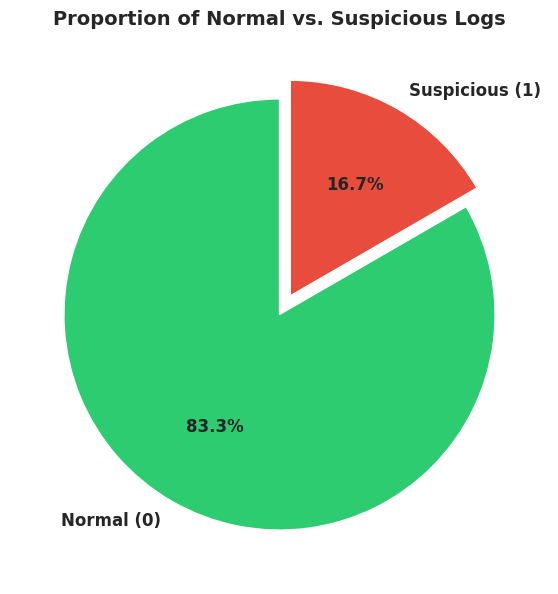

In [4]:
# =====================================================================
# CELL 4.1: TARGET LABEL DISTRIBUTION
# =====================================================================

plt.figure(figsize=(7, 7))
label_counts = df_processed['label'].value_counts()

plt.pie(
    label_counts, 
    labels=['Normal (0)', 'Suspicious (1)'], 
    autopct='%1.1f%%', 
    colors=['#2ecc71', '#e74c3c'], 
    startangle=90, 
    explode=(0, 0.1),
    textprops={'fontsize': 12, 'weight': 'bold'}
)

plt.title("Proportion of Normal vs. Suspicious Logs", fontsize=14, fontweight='bold', pad=15)
plt.show()

/tmp/ipykernel_16/1094974082.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


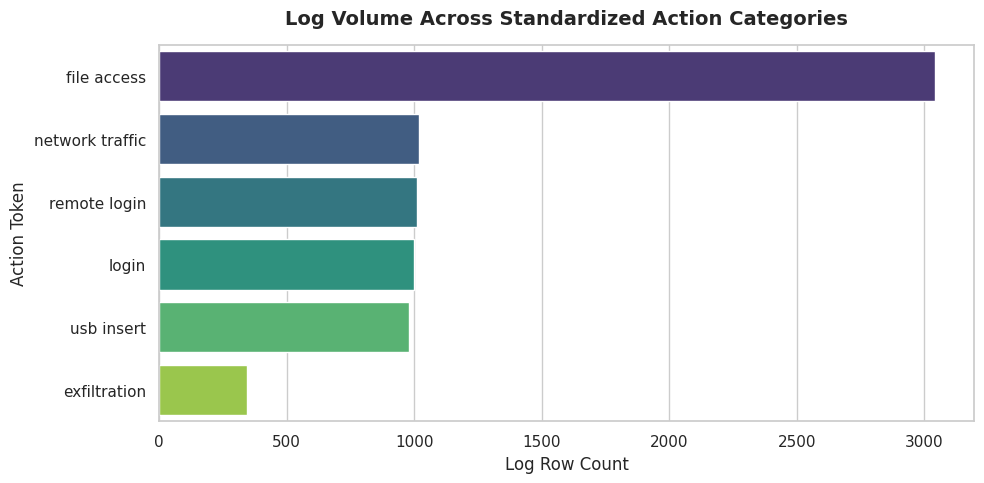

In [5]:
# =====================================================================
# CELL 4.2: EVENT FREQUENCY BY ACTION TYPE
# =====================================================================

plt.figure(figsize=(10, 5))

sns.countplot(
    data=df_processed, 
    y='action', 
    order=df_processed['action'].value_counts().index, 
    palette='viridis'
)

plt.title("Log Volume Across Standardized Action Categories", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Log Row Count", fontsize=12)
plt.ylabel("Action Token", fontsize=12)
plt.tight_layout()
plt.show()

/tmp/ipykernel_16/2004170824.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


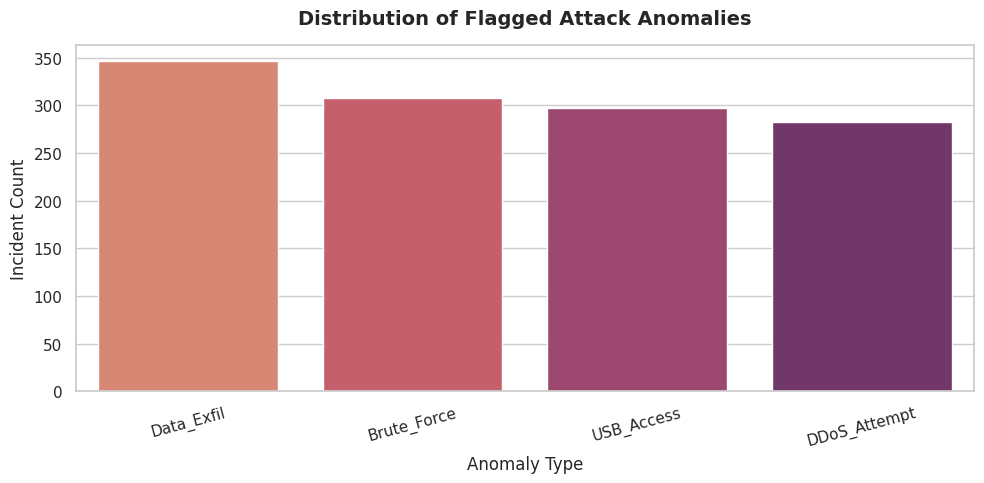

In [6]:
# =====================================================================
# CELL 4.3: ANOMALY VECTOR DISTRIBUTION
# =====================================================================

plt.figure(figsize=(10, 5))

# Filter out 'None' to strictly look at the distributions of actual threat vectors
anomalies_only = df_processed[df_processed['anomaly_type'] != 'None']

sns.countplot(
    data=anomalies_only, 
    x='anomaly_type', 
    order=anomalies_only['anomaly_type'].value_counts().index,
    palette='flare'
)

plt.title("Distribution of Flagged Attack Anomalies", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Anomaly Type", fontsize=12)
plt.ylabel("Incident Count", fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

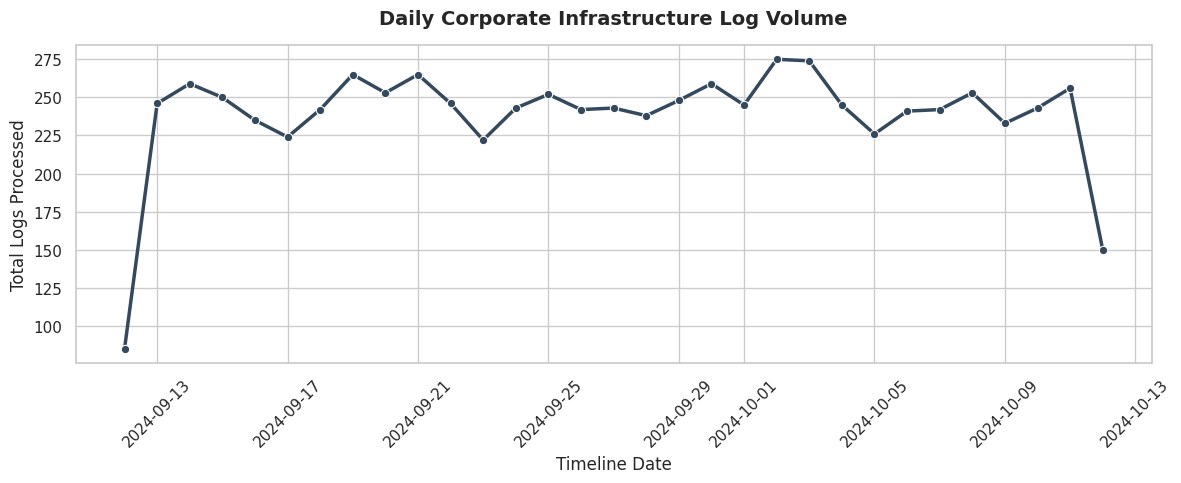

In [7]:
# =====================================================================
# CELL 4.4: SYSTEM ACTIVITY TRENDS OVER TIME
# =====================================================================

plt.figure(figsize=(12, 5))

# Group logs by day
df_daily_trend = df_processed.set_index('timestamp').resample('D').size().reset_index(name='log_count')

sns.lineplot(
    data=df_daily_trend, 
    x='timestamp', 
    y='log_count', 
    marker='o', 
    color='#34495e', 
    linewidth=2.5
)

plt.title("Daily Corporate Infrastructure Log Volume", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Timeline Date", fontsize=12)
plt.ylabel("Total Logs Processed", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_16/2195675620.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


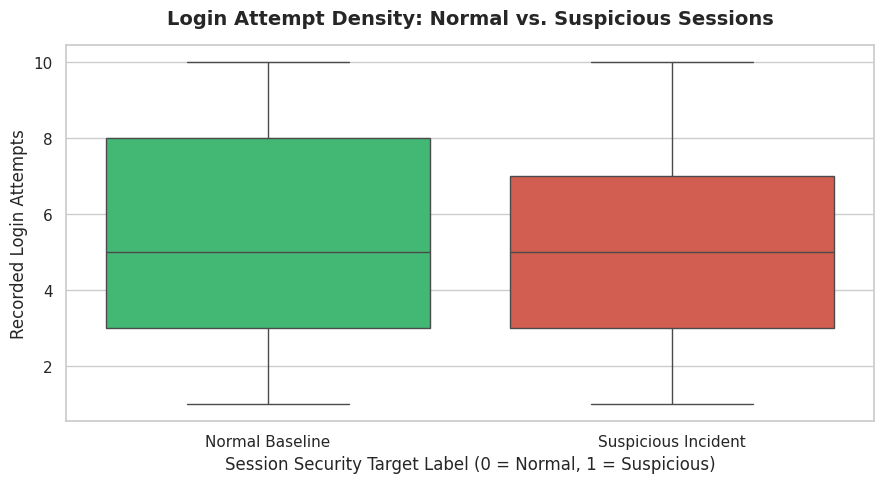

In [8]:
# =====================================================================
# CELL 4.5: AUTHENTICATION STRESS ANALYSIS (BRUTE FORCE CHECK)
# =====================================================================

plt.figure(figsize=(9, 5))

# Using a boxplot to expose outliers and attempt distributions
sns.boxplot(
    data=df_processed[df_processed['action'].isin(['login', 'remote login'])], 
    x='label', 
    y='login_attempts', 
    palette=['#2ecc71', '#e74c3c']
)

plt.title("Login Attempt Density: Normal vs. Suspicious Sessions", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Session Security Target Label (0 = Normal, 1 = Suspicious)", fontsize=12)
plt.ylabel("Recorded Login Attempts", fontsize=12)
plt.xticks([0, 1], ['Normal Baseline', 'Suspicious Incident'])
plt.tight_layout()
plt.show()

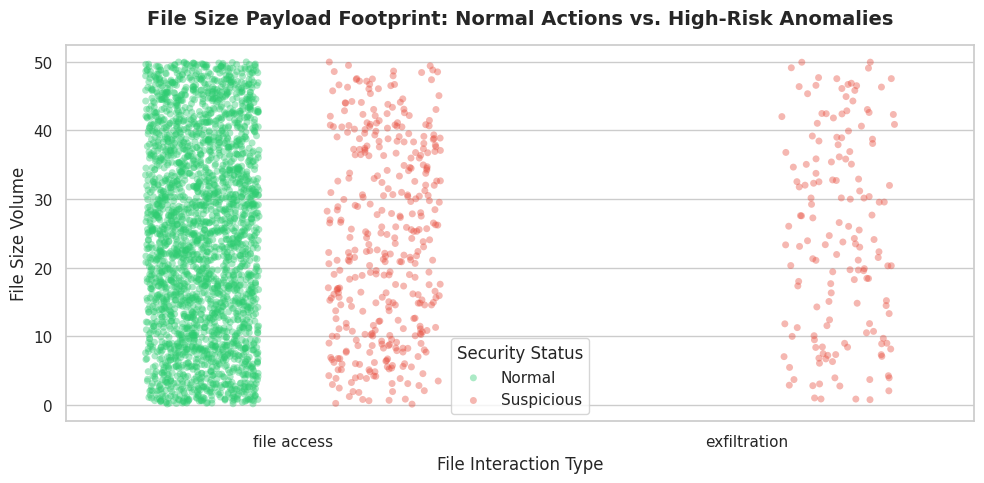

In [9]:
# =====================================================================
# CELL 4.6: LOG PAYLOAD FOOTPRINT (EXFILTRATION SIGNS)
# =====================================================================

plt.figure(figsize=(10, 5))

# Isolate logs that actually involved file interactions with positive file sizes
file_logs = df_processed[(df_processed['file_size'] > 0)]

sns.stripplot(
    data=file_logs, 
    x='action', 
    y='file_size', 
    hue='label', 
    palette=['#2ecc71', '#e74c3c'], 
    dodge=True, 
    alpha=0.4, 
    jitter=0.25
)

plt.title("File Size Payload Footprint: Normal Actions vs. High-Risk Anomalies", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("File Interaction Type", fontsize=12)
plt.ylabel("File Size Volume", fontsize=12)
plt.legend(title="Security Status", labels=["Normal", "Suspicious"])
plt.tight_layout()
plt.show()

## Step 5: Final Export & Generation of the "Data Dictionary"

In [10]:
import os

# Define output path for the processed data file
OUTPUT_DIR = os.path.join("..", "/kaggle/working/")
OUTPUT_FILE = os.path.join(OUTPUT_DIR, "processed_logs.csv")

# Ensure directory exists and save
os.makedirs(OUTPUT_DIR, exist_ok=True)
df_processed.to_csv(OUTPUT_FILE, index=False)
print(f"🎉 Cleaned dataset successfully exported to: {OUTPUT_FILE}\n")

# --- CLEAN UP STRINGS FOR PROFESSIONAL DISPLAY ---
# Convert unique actions into a clean, comma-separated string without brackets or quotes
action_list = ", ".join([f"'{a}'" for a in df_processed['action'].unique()])

# Map messy pandas/numpy dtypes to clean, universal technical names
dtype_mapping = {
    'object': 'String',
    'datetime64[ns]': 'Datetime',
    'int64': 'Integer',
    'float64': 'Float'
}

def get_clean_dtype(col_name):
    raw_dtype = str(df_processed[col_name].dtype)
    return dtype_mapping.get(raw_dtype, raw_dtype)

# --- GENERATE CLEANED DATA DICTIONARY ---
data_dictionary = f"""
### 📖 System Integration Data Dictionary
This file establishes the ground-truth data format generated by the Data Engineer for all modules.

| Field Name | Storage Class | Expected Description / Range |
| :--- | :--- | :--- |
| **user_id** | {get_clean_dtype('user_id')} | Unique string identifier tracking individual corporate employees. |
| **timestamp** | {get_clean_dtype('timestamp')} | Standardized event timeline date and time marker [YYYY-MM-DD HH:MM:SS]. |
| **ip_address** | {get_clean_dtype('ip_address')} | Originating IPv4 network address mapping endpoints. |
| **action** | {get_clean_dtype('action')} | Harmonized behavior tokens: {action_list}. |
| **login_attempts** | {get_clean_dtype('login_attempts')} | Numeric counter of authentication system touches (defaults to 0). |
| **file_size** | {get_clean_dtype('file_size')} | Quantitative file payload footprint magnitude (defaults to 0.0). |
| **anomaly_type** | {get_clean_dtype('anomaly_type')} | Categorical context flagging security vector categories. |
| **label** | {get_clean_dtype('label')} | Ground truth classification target target: [0 = Normal, 1 = Suspicious]. |
"""

print(data_dictionary)

🎉 Cleaned dataset successfully exported to: /kaggle/working/processed_logs.csv


### 📖 System Integration Data Dictionary
This file establishes the ground-truth data format generated by the Data Engineer for all modules.

| Field Name | Storage Class | Expected Description / Range |
| :--- | :--- | :--- |
| **user_id** | String | Unique string identifier tracking individual corporate employees. |
| **timestamp** | Datetime | Standardized event timeline date and time marker [YYYY-MM-DD HH:MM:SS]. |
| **ip_address** | String | Originating IPv4 network address mapping endpoints. |
| **action** | String | Harmonized behavior tokens: 'usb insert', 'remote login', 'login', 'file access', 'network traffic', 'exfiltration'. |
| **login_attempts** | Integer | Numeric counter of authentication system touches (defaults to 0). |
| **file_size** | Float | Quantitative file payload footprint magnitude (defaults to 0.0). |
| **anomaly_type** | String | Categorical context flagging security vector cat